# Baseline evaluation

This notebook runs the evaluation script `evaluate_trip_planning.py` to process the prediction files generated by the Qwen models. It calculates accuracy/scores and generates detailed error logs.

**Models Evaluated:**
1. **Qwen 2.5 7B Instruct**
2. **Qwen 2.5 7B Coder**
3. **Gemini 3.0 Pro**

In [1]:
# Model 1: Qwen 2.5 7B Instruct
# Prediction File: data/qwen2.5-7b/trip_planning_val_results_qwen2.5-7b.json
# Key: pred_5shot_qwen2_5_7b_instruct_bnb_4bit

!python evaluate_trip_planning.py \
  --data_path="data/qwen2.5-7b/trip_planning_val_results_qwen2.5-7b.json" \
  --response_key="pred_5shot_qwen2_5_7b_instruct_bnb_4bit" \
  --error_file_path="data/qwen2.5-7b/trip_planning_errors_qwen2.5-7b.json"

EM Accuracy of 160 samples: 0.025
Updated data/qwen2.5-7b/trip_planning_val_results_qwen2.5-7b.json with scores and parsed plans.
Saved 156 errors to data/qwen2.5-7b/trip_planning_errors_qwen2.5-7b.json


In [2]:
# Model 2: Qwen 2.5 7B Coder
# Prediction File: data/qwen2.5-7b-coder/trip_planning_val_results_qwen2.5-7b-coder.json
# Key: pred_5shot_qwen2_5_coder_7b_instruct_bnb_4bit

!python evaluate_trip_planning.py \
  --data_path="data/qwen2.5-7b-coder/trip_planning_val_results_qwen2.5-7b-coder.json" \
  --response_key="pred_5shot_qwen2_5_coder_7b_instruct_bnb_4bit" \
  --error_file_path="data/qwen2.5-7b-coder/trip_planning_errors_qwen2.5-7b-coder.json"

EM Accuracy of 160 samples: 0.05
Updated data/qwen2.5-7b-coder/trip_planning_val_results_qwen2.5-7b-coder.json with scores and parsed plans.
Saved 152 errors to data/qwen2.5-7b-coder/trip_planning_errors_qwen2.5-7b-coder.json


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


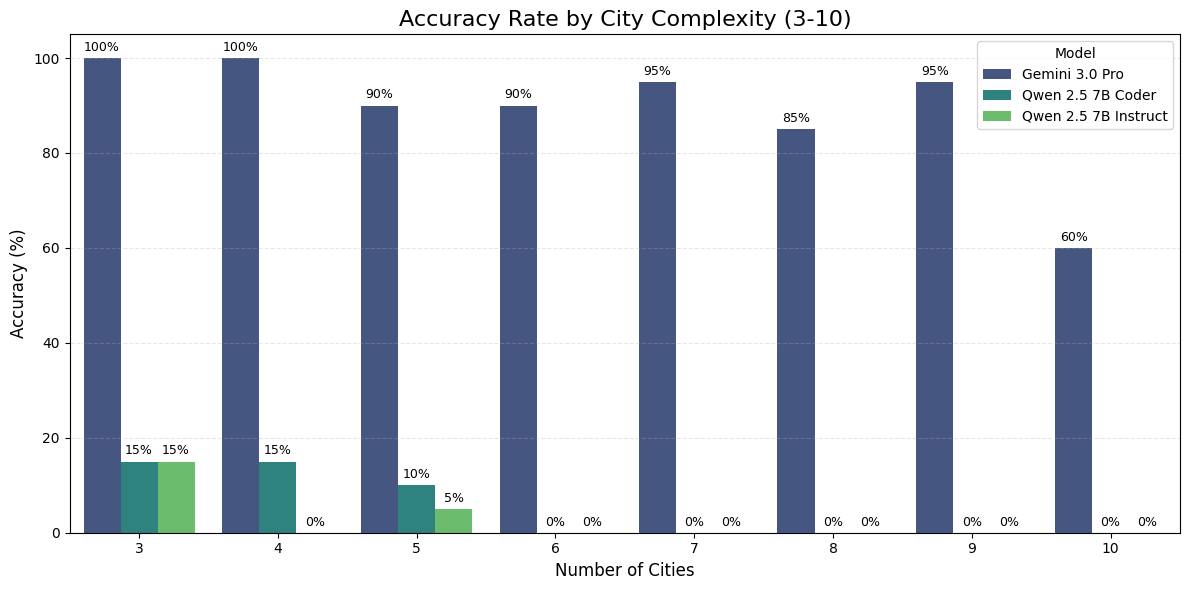

In [5]:
%pip install seaborn
# --- Visualization: Accuracy by City Complexity ---
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json

# 1. Define File Paths & Keys
files = {
    "Gemini 3.0 Pro": {
        "path": "data/gemini3-pro/trip_planning_val_results_gemini3-pro.json",
        "key": "gemini3.0-pro"
    },
    "Qwen 2.5 7B Instruct": {
        "path": "data/qwen2.5-7b/trip_planning_val_results_qwen2.5-7b.json",
        "key": "pred_5shot_qwen2_5_7b_instruct_bnb_4bit"
    },
    "Qwen 2.5 7B Coder": {
        "path": "data/qwen2.5-7b-coder/trip_planning_val_results_qwen2.5-7b-coder.json",
        "key": "pred_5shot_qwen2_5_coder_7b_instruct_bnb_4bit"
    }
}

data_points = []

# 2. Load Data & Calculate Accuracy
for model_name, config in files.items():
    try:
        with open(config["path"], "r", encoding="utf-8") as f:
            data = json.load(f)
        
        # Handle list vs dict format
        items = data.values() if isinstance(data, dict) else data
        
        for item in items:
            # Extract Complexity (Num Cities)
            # Use 'num_cities' field if available, otherwise count cities string
            num_cities = int(item.get('num_cities', 0))
            if num_cities == 0 and 'cities' in item:
                num_cities = len(item['cities'].split('**'))
            
            # Extract Score (Assume evaluated with 'score' or calculate it?)
            # Note: evaluate_trip_planning.py adds 'score' field to the file.
            score = item.get('score', 0.0)
            
            data_points.append({
                "Model": model_name,
                "Complexity": num_cities,
                "Score": score
            })
            
    except FileNotFoundError:
        print(f"Warning: File not found for {model_name}")

# 3. Create DataFrame
df = pd.DataFrame(data_points)

# Filter for specific range 3-10 if needed (Dataset is typically 7-odd? Let's keep all valid)
df = df[df['Complexity'].between(3, 10)]

# 4. Aggregate Accuracy by Complexity
accuracy_df = df.groupby(['Model', 'Complexity'])['Score'].mean().reset_index()
accuracy_df['Accuracy (%)'] = accuracy_df['Score'] * 100

# 5. Plot
plt.figure(figsize=(12, 6))
# Use a consistent palette
sns.barplot(data=accuracy_df, x='Complexity', y='Accuracy (%)', hue='Model', palette='viridis')

plt.title('Accuracy Rate by City Complexity (3-10)', fontsize=16)
plt.xlabel('Number of Cities', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add labels on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f%%', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('complexity_accuracy_analysis.png')
plt.show()
